In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

In [ ]:
#Load dataset
df = pd.read_csv('/content/Bangladesh_Crime_Dataset_B.csv')

#Head of dataset
df.head()

,Unnamed: 0,incident_month,incident_week,incident_weekday,weekend,part_of_the_day,incident_district,incident_division,precip,visibility,...,average_household_size,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college,crime
0,0,7,29,wednesday,0,morning,dhaka,dhaka,6.1,10,...,8.42,30551,74.6,4289,99,17,60,242,64,murder
1,1,1,2,wednesday,0,night,dhaka,dhaka,0.0,10,...,8.42,30551,74.6,4289,99,17,60,242,64,murder
2,2,1,4,tuesday,0,night,dhaka,dhaka,0.0,10,...,8.42,30551,74.6,4289,99,17,60,242,64,murder
3,3,3,9,friday,1,night,dhaka,dhaka,0.0,10,...,8.42,30551,74.6,4289,99,17,60,242,64,murder
4,4,8,34,thursday,0,night,dhaka,dhaka,21.9,9,...,8.42,30551,74.6,4289,99,17,60,242,64,murder


In [ ]:
df.shape

(6574, 26)

Dataset memiliki 6574 baris dan 26 kolom.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6574 entries, 0 to 6573
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              6574 non-null   int64  
 1   incident_month          6574 non-null   int64  
 2   incident_week           6574 non-null   int64  
 3   incident_weekday        6574 non-null   object 
 4   weekend                 6574 non-null   int64  
 5   part_of_the_day         6457 non-null   object 
 6   incident_district       6574 non-null   object 
 7   incident_division       6574 non-null   object 
 8   precip                  5917 non-null   float64
 9   visibility              6574 non-null   int64  
 10  heatindex               6574 non-null   int64  
 11  season                  6246 non-null   object 
 12  male_population         6574 non-null   int64  
 13  female_population       6574 non-null   int64  
 14  total_population        6574 non-null   

## a. Conduct an Exploratory Data Analysis (EDA) on the dataset. Highlight the main insights and any irregularities you find, and address those anomalies appropriately!

In [ ]:
#Drop Columns
df = df.drop(columns=["Unnamed: 0", "incident_week", "male_population", "female_population", "incident_district"])

1. Unnamed: 0 -> Kolom ini hanya berisi nomor urut (index) yang tidak memiliki makna dalam analisis, sehingga tidak memberikan informasi untuk EDA atau clustering, sehingga dihapus agar tidak memengaruhi hasil.

2. incident_week -> Karena informasi waktu kejadian sudah tercakup oleh incident_month dan incident_weekday, kolom incident_week menjadi redundant dan tidak diperlukan untuk analisis, sehingga dihapus untuk menjaga kesederhanaan data.

3. male_population & female_population -> Kedua kolom ini sangat berkorelasi dan sebenarnya sudah terwakili oleh total_population dan gender_ratio, sehingga mempertahankannya dapat menyebabkan redundansi dan mengganggu hasil K-Means.

4. incident_district -> terlalu detail dan informasinya sudah terwakili oleh incident_division, di drop agar datanya lebih ringkas dan mudah dianalisis.

In [ ]:
#Check Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6574 entries, 0 to 6573
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   incident_month          6574 non-null   int64  
 1   incident_weekday        6574 non-null   object 
 2   weekend                 6574 non-null   int64  
 3   part_of_the_day         6457 non-null   object 
 4   incident_division       6574 non-null   object 
 5   precip                  5917 non-null   float64
 6   visibility              6574 non-null   int64  
 7   heatindex               6574 non-null   int64  
 8   season                  6246 non-null   object 
 9   total_population        6574 non-null   int64  
 10  gender_ration           6574 non-null   int64  
 11  average_household_size  6574 non-null   float64
 12  density_per_kmsq        6574 non-null   int64  
 13  literacy_rate           6246 non-null   float64
 14  religious_institution   6574 non-null   

Semua kolom sudah memiliki tipe data yang sesuai.

In [ ]:
#Rename Column
df.rename(columns={"gender_ration": "gender_ratio"}, inplace=True)

Kolom gender_ration diganti menjadi gender_ratio agar nama kolom lebih jelas serta konsisten.

### Check Data Problems

In [ ]:
#Check Duplicates
df.duplicated().sum()

np.int64(304)

Terdapat 304 baris duplikat.

In [ ]:
#Handle Duplicates
df = df.drop_duplicates()

Semua baris yang duplikat di drop agar analisis tidak bias dan tidak memengaruhi clustering.

In [ ]:
#Check Inconsistent
for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].dropna().unique())


Column: incident_month
[ 7  1  3  8  2 11  9  6  4  5 10 12]

Column: incident_weekday
['wednesday' 'tuesday' 'friday' 'thursday' 'thursay' 'sunday' 'saturday'
 'monday' 'montay' 'tlesday' 'monmday' 'wdenesday' 'sundaoy' 'frida'
 'thursduay' 'firday' 'sundya' 'sdunday' 'tuyesday' 'wednescay'
 'wednerday' 'thusrday' 'riday' 'satturday' 'thirsday' 'saaturday'
 'saturdau' 'nsaturday' 'thusday' 'wonday' 'suniday' 'frikay' 'satruday'
 'sturday' 'ewdnesday' 'saturdya' 'thjursday' 'wednedsay' 'tuesoday'
 'tuesdy' 'khursday' 'satdurday' 'snuday' 'tuesdya' 'htursday' 'tuesdsy'
 'mnoday' 'hhursday' 'wunday' 'tuesdiy' 'fridjay' 'omnday' 'tuesdmay'
 'suday' 'thursdaqy' 'froiday' 'tyesday' 'sznday' 'thurday' 'sautrday'
 'friady' 'tuesdsay' 'syturday' 'thursdya' 'staurday' 'sundy' 'tuesdby'
 'tueslay' 'wednesda' 'wednesdany' 'thursady' 'eunday' 'tuseday' 'onday'
 'thursdy' 'wdnesday' 'thursdaay' 'saturlay' 'sundiy' 'wednsday' 'fridak'
 'saturhay' 'mondjay' 'wedneuday' 'monda' 'aturday' 'mopnday' 's

1. incident_weekday: banyak typo dan variasi penulisan hari, sehingga data tidak konsisten karena seharusnya hanya 7 nilai (Monday–Sunday).

2. religious_institution: terdapat nilai negatif, padahal jumlah institusi tidak mungkin bernilai negatif, menunjukkan data error.

3. police_station: terdapat nilai negatif, yang tidak masuk akal karena jumlah kantor polisi tidak bisa negatif, menandakan data salah input.

4. season: “hot” tidak konsisten dengan nama season standar, sehingga perlu diperbaiki menjadi “summer” agar lebih jelas dan konsisten.

In [ ]:
#Check Missing Values
df.isna().sum()

,0
incident_month,0
incident_weekday,0
weekend,0
part_of_the_day,117
incident_division,0
precip,656
visibility,0
heatindex,0
season,328
total_population,0


Kolom dengan missing value:
1. part_of_the_day -> 117 missing
2. precip -> 656 missing
3. season -> 328 missing
4. literacy_rate -> 328 missing

In [ ]:
#Check Outliers
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) | (df[col] > upper_bound)
    ][col]

    outlier_summary.append({
        'column': col,
        'outlier_count': outliers.shape[0],
        'outlier_min': outliers.min() if not outliers.empty else None,
        'outlier_max': outliers.max() if not outliers.empty else None
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df[outlier_df['outlier_count'] > 0]

,column,outlier_count,outlier_min,outlier_max
2,precip,586,18.80,204.60
3,visibility,306,4.00,7.00
5,total_population,1191,1820374.00,8906039.00
6,gender_ratio,6,203.00,203.00
7,average_household_size,822,8.42,8.42
8,density_per_kmsq,1207,13183.00,30551.00
10,religious_institution,833,2949.00,4289.00
11,playground,87,192.00,253.00
12,park,1229,8.00,17.00
13,police_station,1162,13.00,74.00


1. precip (586 outlier, 18.80–204.60): curah hujan yang sangat tinggi bisa jadi outlier karena jauh dari nilai normal harian, sehingga perlu dicek apakah valid atau error input.
2. visibility (306 outlier, 4.00–7.00): nilai visibilitas rendah ini bisa menunjukkan kondisi ekstrem (kabut/curah hujan besar) dan perlu dipertimbangkan sebagai outlier.
3. total_population (1191 outlier, 1.8 juta–8.9 juta): beberapa distrik besar punya populasi sangat tinggi dibanding yang lain, sehingga ini outlier dan bisa memengaruhi clustering.
4. gender_ratio (6 outlier, 203): rasio jenis kelamin sangat ekstrem dan tidak umum, kemungkinan error input atau data tidak representatif.
5. average_household_size (822 outlier, 8.42): ukuran rumah tangga yang sangat besar ini tidak wajar dan cenderung data error.
6. density_per_kmsq (1207 outlier, 13.183–30.551): kepadatan penduduk sangat tinggi pada beberapa wilayah besar, bisa valid tapi tetap outlier yang memengaruhi clustering.
7. religious_institution (833 outlier, 2949–4289): jumlah institusi keagamaan sangat tinggi dan tidak wajar, kemungkinan error data atau outlier ekstrem.
8. playground (87 outlier, 192–253): jumlah playground yang sangat banyak pada beberapa area, bisa jadi outlier atau area khusus.
9. park (1229 outlier, 8–17): jumlah park yang sangat sedikit dibanding area lain, ini outlier dan perlu dicek apakah data memang sedikit atau error.
10. police_station (1162 outlier, 13–74): jumlah kantor polisi yang sangat tinggi pada beberapa area, bisa valid untuk kota besar tapi tetap outlier.
11. school (822 outlier, 242): jumlah sekolah sangat tinggi pada beberapa area, bisa karena wilayah besar atau data error.
12. college (844 outlier, 33–64): jumlah perguruan tinggi yang sangat tinggi pada beberapa area, bisa valid untuk kota besar tapi tetap outlier.

## Handle Data Problems

### Handle Inconsistent

In [ ]:
#Hanlde Inconsistent Weekday Name
from difflib import get_close_matches

valid_weekdays = ["monday", "tuesday", "wednesday", "thursday", "friday", "saturday", "sunday"]

def clean_incident_weekday(value):
    if pd.isna(value):
        return pd.NA

    value = (str(value).lower().strip().replace(" ", ""))

    match = get_close_matches(value, valid_weekdays, n=1, cutoff=0.6)

    return match[0] if match else pd.NA

df["incident_weekday"] = df["incident_weekday"].apply(clean_incident_weekday)

Karena kolom incident_weekday banyak typo dan variasi penulisan, fungsi ini digunakan untuk membersihkan dan menyamakan nilai hari. Dengan mengubah teks menjadi lowercase, menghapus spasi, lalu mencocokkan ke daftar hari yang valid menggunakan fuzzy matching, maka nilai yang mirip akan dikoreksi menjadi nama hari yang benar. Jika tidak ada kecocokan, maka dikosongkan (NA) untuk menghindari data salah.

In [ ]:
#Replace Hot -> Summer
season_mapping = {"hot": "summer"}
df["season"] = (df["season"].str.lower().replace(season_mapping))

Untuk mengubah semua teks season jadi huruf kecil lalu mengganti “hot” menjadi “summer”, digunakan lower dan replace agar nama musimnya konsisten.

In [ ]:
#Handle Inconsistent in religious_institution and police_station
df.loc[df["religious_institution"] < 0, "religious_institution"] = np.nan
df.loc[df["police_station"] < 0, "police_station"] = np.nan

Nilai yang kurang dari 0 pada kolom religious_institution dan police_station diubah menjadi NaN (missing), karena jumlah institusi atau kantor polisi tidak mungkin bernilai negatif.

### Handle Missing Value

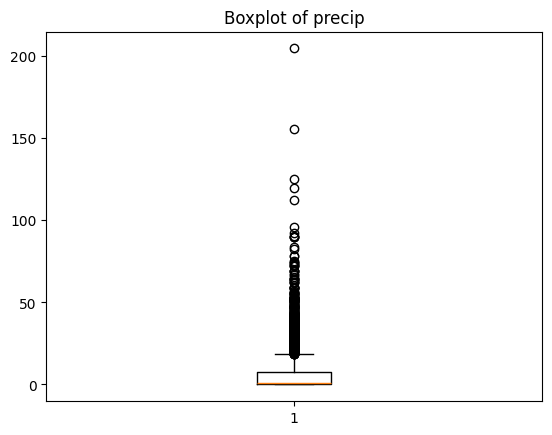

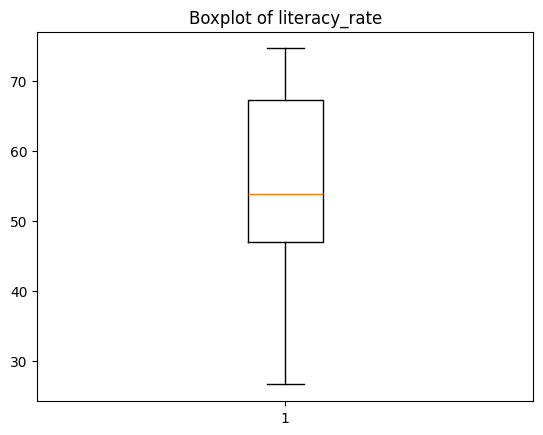

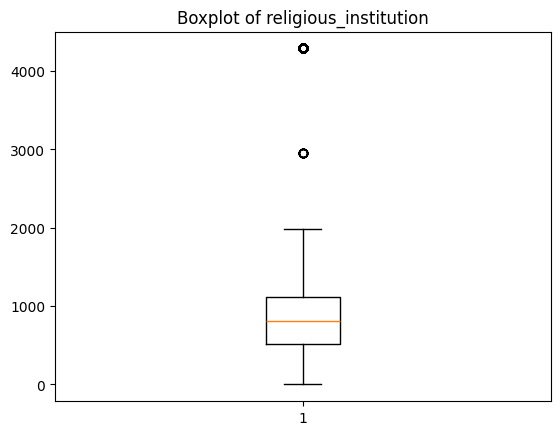

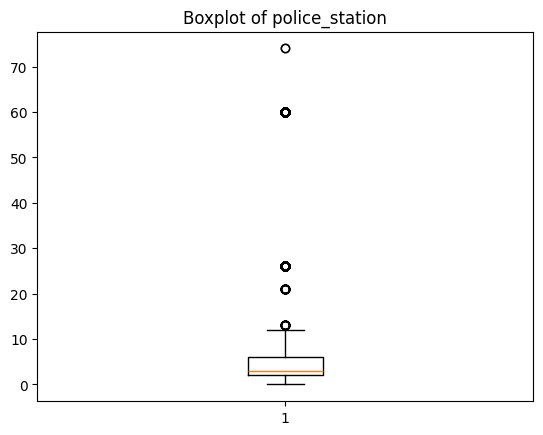

In [ ]:
num_cols = ["precip", "literacy_rate", "religious_institution","police_station"]

for col in num_cols:
    plt.figure()
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.show()

In [ ]:
literacy_mean = df["literacy_rate"].mean()
df["literacy_rate"].fillna(literacy_mean, inplace=True)

In [ ]:
ri_median = df["religious_institution"].median()
df["religious_institution"].fillna(ri_median, inplace=True)

In [ ]:
ps_median = df["police_station"].median()
df["police_station"].fillna(ps_median, inplace=True)

In [ ]:
precip_median =df["precip"].median()
df["precip"].fillna(precip_median, inplace=True)

Karena beberapa kolom numerik ada missing value, maka missing tersebut diganti dengan nilai yang lebih representatif agar data lengkap untuk analisis dan clustering.
1. literacy_rate diisi dengan mean (rata-rata) karena distribusinya cenderung normal.
2. religious_institution, police_station, precip diisi dengan median karena data tersebut bisa punya nilai ekstrem (outlier), sehingga median lebih aman dan tidak terpengaruh outlier.

In [ ]:
season_mode = df["season"].mode()[0]
df["season"].fillna(season_mode, inplace=True)

In [ ]:
potd_mode= df["part_of_the_day"].mode()[0]
df["part_of_the_day"].fillna(potd_mode, inplace=True)

In [ ]:
weekdays_mode= df["incident_weekday"].mode()[0]
df["incident_weekday"].fillna(weekdays_mode, inplace=True)

Karena beberapa kolom kategorikal ada missing value, maka missing tersebut diganti dengan nilai modus.


Missing values tidak di-drop karena jumlahnya cukup signifikan sehingga penghapusan baris akan menyebabkan kehilangan data yang besar dan berpotensi mengubah distribusi data, yang pada akhirnya dapat menimbulkan bias pada model. Selain itu, nilai yang hilang belum tentu bersifat acak dan bisa mengandung informasi penting terkait kondisi tertentu (misalnya data cuaca yang tidak tercatat). Oleh karena itu, imputasi dipilih sebagai solusi yang lebih tepat agar informasi tetap terjaga dan model dapat belajar dari data yang lebih lengkap.

### Handle Outliers

In [ ]:
#Capping
def iqr_capping(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower,
                       np.where(df[col] > upper, upper, df[col]))
    return df

#Log Transform
def log_transform(df, col):
    df[col] = np.log1p(df[col])
    return df

features_iqr = ["precip", "religious_institution", "park", "police_station", "college"]

features_log = ["total_population", "density_per_kmsq"]

for col in features_iqr:
    df = iqr_capping(df, col)

for col in features_log:
    df = log_transform(df, col)

df.describe()



,incident_month,weekend,precip,visibility,heatindex,total_population,gender_ratio,average_household_size,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college
count,6270.000000,6270.000000,6270.000000,6270.000000,6270.000000,6270.000000,6270.000000,6270.000000,6270.000000,6270.000000,6270.000000,6270.000000,6270.000000,6270.000000,6270.000000,6270.000000
mean,6.221372,0.273844,3.840463,9.484689,31.631898,13.259795,104.387400,4.957107,7.653641,55.772147,925.047927,42.752951,2.344896,4.704466,75.171451,11.142424
std,3.313346,0.445965,5.454231,0.925872,5.480027,1.294976,10.307631,1.417070,1.383911,11.716601,536.719472,45.107002,2.825617,3.965342,71.400471,9.542417
min,1.000000,0.000000,0.000000,4.000000,15.000000,10.037669,84.000000,3.580000,3.178054,26.700000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,3.000000,0.000000,0.000000,9.000000,27.000000,12.488530,98.000000,4.110000,6.829794,47.400000,522.000000,5.000000,0.000000,2.000000,30.000000,4.000000
50%,6.000000,0.000000,0.800000,10.000000,33.000000,12.848211,101.000000,4.440000,7.122867,54.800000,815.000000,25.000000,1.000000,3.000000,45.000000,8.000000
75%,9.000000,1.000000,6.100000,10.000000,36.000000,13.561565,109.000000,5.040000,8.288534,65.400000,1121.000000,78.000000,3.000000,6.000000,86.000000,15.000000
max,12.000000,1.000000,15.250000,10.000000,43.000000,16.002240,203.000000,8.420000,10.327185,74.600000,2019.500000,253.000000,7.500000,12.000000,242.000000,31.500000


Kolom yang dihandle:
1. Precip: outlier banyak dan nilai ekstrem (max 204.60), bisa merusak model, jadi menggunakan IQR capping
2. Total_population: nilai sangat besar (jutaan), lebih tepat menggunakan log transform daripada cap
3. Density_per_kmsq: nilai besar dan skewed, menggunakan log transform agar distribusi lebih normal
4. Religious_institution: outlier banyak dan nilai tinggi, menggunakan IQR capping untuk mengurangi bias
5. Park, Police_station, College: outlier banyak sehingga distribusi skewed, menggunakan IQR capping


Kolom yang tidak dihandle:
1. Gender_ratio: outlier sedikit dan nilai masih realistis, tidak perlu di-handle
2. Average_household_size: nilai masih mungkin realistis, tidak perlu di-handle
3. Playground, School: outlier sedikit dan masih realistis, tidak perlu di-handle

## Change Month from Integer to Category

In [ ]:
month_map = {
    1: "January", 2: "February", 3: "March", 4: "April",
    5: "May", 6: "June", 7: "July", 8: "August",
    9: "September", 10: "October", 11: "November", 12: "December"
}

df["incident_month"] = df["incident_month"].map(month_map).astype("category")

incident_month diubah menjadi kategori (nama bulan) karena bulan bersifat siklik dan tidak memiliki urutan numerik yang bermakna untuk jarak. Jika tetap menggunakan angka 1–12, K-Means akan menganggap bulan Januari dan Desember jauh, padahal secara waktu mereka berdekatan, sehingga dapat menghasilkan clustering yang tidak akurat.

## Encoding

In [ ]:
#One Hot Encoding
from sklearn.preprocessing import OneHotEncoder

encode_cols = ["incident_month", "incident_weekday", "part_of_the_day", "incident_division", "season"]

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded = encoder.fit_transform(df[encode_cols])
encoded_features = encoder.get_feature_names_out(encode_cols)
encoded_df = pd.DataFrame(encoded, columns=encoded_features, index=df.index)

df = pd.concat([df.drop(encode_cols, axis=1), encoded_df], axis=1)

One Hot Encoding digunakan karena sebagian besar fitur kategorikal pada dataset ini bersifat nominal dan tidak memiliki urutan alami, seperti incident_month, incident_weekday, part_of_the_day,  incident_division, dan season. Jika kategori seperti ini diubah menjadi angka biasa (misalnya label encoding), model bisa salah mengartikan adanya hubungan urutan atau jarak antar kategori (contoh: “monday < friday”), padahal hubungan tersebut tidak ada secara konseptual. Dengan One Hot Encoding, setiap kategori direpresentasikan sebagai fitur biner yang independen, sehingga model dapat mempelajari pengaruh masing-masing kategori secara adil tanpa asumsi urutan atau skala tertentu, dan hasil model menjadi lebih stabil serta interpretasinya lebih masuk akal.

## Scaling

In [ ]:
from sklearn.preprocessing import RobustScaler

num_cols = [
    "weekend",
    "precip",
    "visibility",
    "heatindex",
    "total_population",
    "gender_ratio",
    "average_household_size",
    "density_per_kmsq",
    "literacy_rate",
    "religious_institution",
    "playground",
    "park",
    "police_station",
    "school",
    "college"
]

scaler = RobustScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

RobustScaler dipilih karena lebih tahan terhadap outlier dan distribusi skewed, sehingga skala fitur tidak dipengaruhi nilai ekstrem yang masih mungkin ada pada data. StandardScaler tidak dipakai karena meskipun beberapa kolom tidak skew, ada kolom lain yang memiliki nilai ekstrem dan distribusi tidak normal, sehingga mean dan standard deviation menjadi tidak representatif. Jika memakai StandardScaler, outlier dapat mendominasi jarak Euclidean pada K-Means dan menyebabkan clustering tidak stabil. Dengan RobustScaler, semua fitur tetap distandarisasi dengan aman meskipun ada skew atau outlier.

## b. Train K-Means and tune it based on a minimum of two metrics. Afterward, visualize the final clusters!

In [ ]:
x_cluster = df.drop(columns=["crime"])

In [ ]:
#Metric 1 (Silhouette Score)
#Metric 2 (Davies–Bouldin Index)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

silhouette_scores = []
db_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(x_cluster)

    silhouette_scores.append(silhouette_score(x_cluster, labels))
    db_scores.append(davies_bouldin_score(x_cluster, labels))

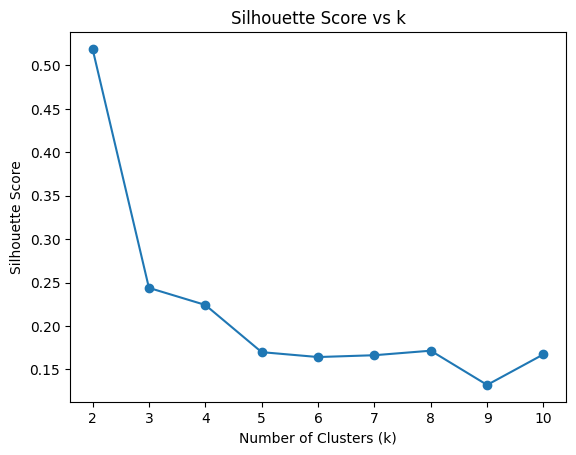

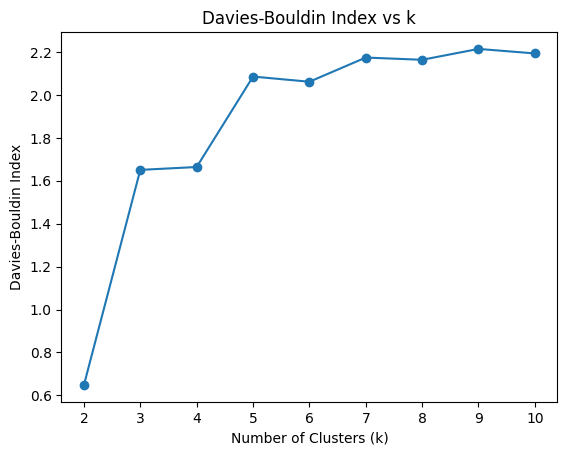

In [ ]:
#Plot for Metric 1 and Metric 2
import matplotlib.pyplot as plt

plt.figure()
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.show()

plt.figure()
plt.plot(k_range, db_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Davies-Bouldin Index")
plt.title("Davies-Bouldin Index vs k")
plt.show()

* Silhouette Score paling tinggi di k = 2, lalu turun saat jumlah
cluster bertambah, artinya pemisahan cluster paling jelas terjadi saat 2 cluster.

* Davies-Bouldin Index paling rendah juga di k = 2, semakin kecil nilainya, semakin bagus kualitas cluster.

In [ ]:
# Train K-Means Final (k -> 2)
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(x_cluster)

df["cluster"] = cluster_labels

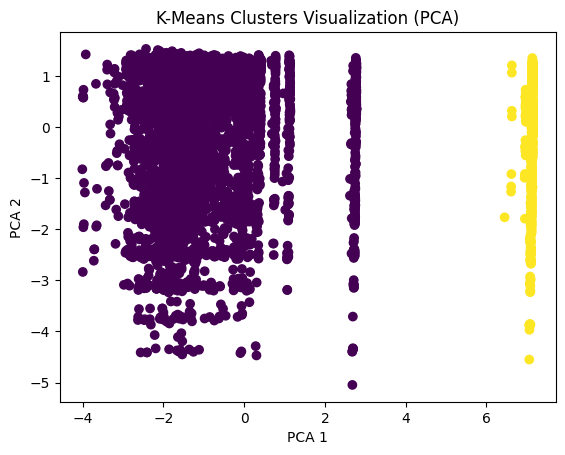

In [ ]:
#Visualization use PCA 2D
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
x_pca = pca.fit_transform(x_cluster)

plt.figure()
plt.scatter(
    x_pca[:, 0],
    x_pca[:, 1],
    c=cluster_labels
)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clusters Visualization (PCA)")
plt.show()

Visualisasi PCA menunjukkan bahwa hasil K-Means dengan k = 2 membagi data ke dalam dua kelompok yang terpisah cukup jelas, terutama pada sumbu PCA 1. Hal ini menandakan bahwa terdapat perbedaan karakteristik yang kuat antara kedua cluster. Cluster pertama (ungu) mencakup sebagian besar data dan menunjukkan pola yang relatif beragam, sedangkan cluster kedua (kuning) berada cukup jauh dari kelompok utama, yang mengindikasikan area dengan karakteristik yang berbeda secara signifikan, seperti perbedaan pada faktor demografis, kepadatan penduduk, atau ketersediaan infrastruktur. Secara keseluruhan, pemisahan ini mendukung hasil evaluasi metrik clustering yang menyatakan bahwa dua cluster sudah cukup untuk merepresentasikan pola utama dalam data.

## c. Profile each cluster to understand its customer characteristics!

In [ ]:
#Numeric
profile_numeric = [
    "total_population",
    "density_per_kmsq",
    "literacy_rate",
    "average_household_size",
    "police_station",
    "school",
    "park",
    "heatindex",
    "precip"
]

numeric_profile = (df.groupby("cluster")[profile_numeric].mean().round(2))

numeric_profile

,total_population,density_per_kmsq,literacy_rate,average_household_size,police_station,school,park,heatindex,precip
cluster,,,,,,,,,
0,-0.00,0.09,-0.10,-0.01,0.15,0.09,0.19,-0.16,0.51
1,2.94,2.20,1.05,4.28,2.25,3.52,2.17,-0.11,0.43


* Cluster 0 merepresentasikan wilayah dengan karakteristik mendekati rata-rata, kepadatan dan infrastruktur relatif rendah, sehingga cenderung wilayah non-perkotaan.
* Cluster 1 menunjukkan wilayah dengan populasi, kepadatan, literasi, dan infrastruktur publik yang jauh lebih tinggi, yang mengindikasikan area perkotaan dengan aktivitas sosial yang lebih intens.

In [ ]:
#Weekend
weekend_profile = df.groupby("cluster")["weekend"].mean().round(2)

weekend_profile

,weekend
cluster,
0,0.27
1,0.27


Nilai weekend yang sama (0,27) pada kedua cluster menunjukkan bahwa proporsi kejahatan di akhir pekan relatif serupa, sehingga hari kejadian bukan faktor pembeda utama antar cluster.

In [ ]:
#Part of the Day
part_of_day_cols = [c for c in df.columns if c.startswith("part_of_the_day_")]
day_profile = df.groupby("cluster")[part_of_day_cols].mean().round(2)

day_profile

,part_of_the_day_afternoon,part_of_the_day_evening,part_of_the_day_morning,part_of_the_day_night,part_of_the_day_noon
cluster,,,,,
0,0.05,0.07,0.31,0.5,0.07
1,0.07,0.08,0.24,0.5,0.11


Pada kedua cluster, kejahatan paling banyak terjadi pada malam hari (50%). Cluster 0 lebih dominan pada pagi hari, sedangkan Cluster 1 menunjukkan distribusi waktu yang lebih merata hingga siang hari, mencerminkan aktivitas wilayah yang lebih tinggi.

In [ ]:
#Season
season_cols = [c for c in df.columns if c.startswith("season_")]
season_profile = df.groupby("cluster")[season_cols].mean().round(2)

season_profile

,season_rainy,season_summer,season_winter
cluster,,,
0,0.46,0.26,0.27
1,0.48,0.24,0.28


Pada kedua cluster, kejahatan paling banyak terjadi pada musim hujan, dan distribusi musim relatif mirip, sehingga musim bukan pembeda utama antar cluster.

In [ ]:
#Crime Distribution
crime_profile = (
    df[["cluster", "crime"]].value_counts(normalize=True).mul(100).round(2).reset_index(name="percentage"))

crime_profile

,cluster,crime,percentage
0,0,murder,21.16
1,0,bodyfound,19.78
2,0,rape,16.06
3,0,assault,14.50
4,0,kidnap,8.84
5,0,robbery,6.56
6,1,bodyfound,3.56
7,1,robbery,2.39
8,1,assault,2.38
9,1,murder,1.91


Cluster 0 didominasi oleh kejahatan berat seperti murder, body found, dan rape, sedangkan Cluster 1 memiliki proporsi kejahatan yang lebih rendah dan lebih tersebar, dengan body found dan robbery sebagai yang paling menonjol.

## Kesimpulan

Analisis clustering berhasil mengelompokkan wilayah kejadian kriminal di Bangladesh ke dalam dua cluster utama dengan karakteristik yang berbeda. Cluster 0 merepresentasikan wilayah dengan karakteristik mendekati rata-rata nasional dan didominasi oleh kejahatan berat seperti murder, body found, dan rape, yang sebagian besar terjadi pada malam hari dan musim hujan. Sementara itu, Cluster 1 mencerminkan wilayah dengan populasi, kepadatan, dan infrastruktur publik yang lebih tinggi, namun dengan intensitas kejahatan yang relatif lebih rendah dan pola waktu serta musim yang serupa.

## Insight

Insight utama dari hasil ini menunjukkan bahwa faktor demografis dan infrastruktur wilayah lebih berpengaruh dalam membedakan pola kejahatan dibandingkan faktor waktu dan musim. Oleh karena itu, strategi kepolisian sebaiknya difokuskan pada peningkatan pengamanan malam hari, terutama di wilayah Cluster 0, serta pendekatan pencegahan berbasis wilayah yang disesuaikan dengan karakteristik masing-masing cluster untuk mendukung kebijakan keamanan yang lebih efektif dan tepat sasaran.